In [ ]:
!pip install tensorflow

In [ ]:
%pip install camel-tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.3/124.3 kB 707.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 22.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for camel-kenlm: filename=camel_kenlm-2023.3.17.2-cp310-cp310-linux_x86_64.whl size=3453126 sha256=538db663559103a086e4a2fea3cb4548513e163a81f42dc95e780b880953e0e3
  Stored in directory: /root/.cache/pip/wheels/29/c5/32/09633c3b70fdfc470b2fb912bd9e90d8d6814df68c794dcaa6
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=61fc8769d32ba03b9eaf6a06c6159190f9

In [ ]:
!pip install pyarabic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 1.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re



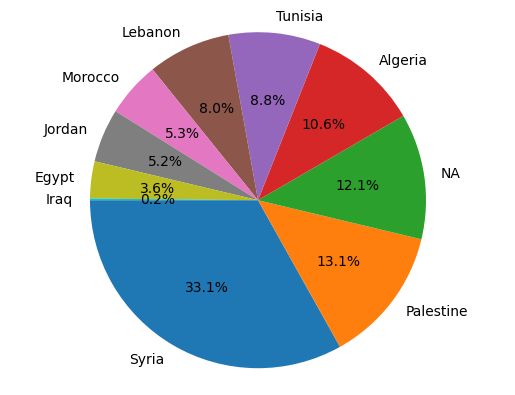

In [ ]:
IADD = pd.read_json('/content/drive/MyDrive/IADD.json')
import matplotlib.pyplot as plt

country_counts =IADD["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/nlp/dialects01.csv')

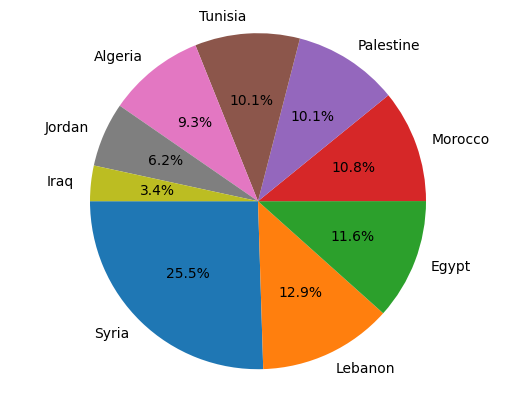

In [ ]:
import matplotlib.pyplot as plt

country_counts =df["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
df = df.drop_duplicates(subset=['Sentence'])
df

,Sentence,Country
0,هه اصلا حاليا فى وفد قطري موجود بغزه واللعبه ...,Palestine
1,عادي طعميها لأنها ما راح تكتفي من صدرك صار بد...,Palestine
2,اعملي اللي عليكي لوجه الله,Palestine
3,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شا...,Palestine
4,و هيا وإياه بتزوجو هه,Palestine
...,...,...
170584,في مكتبة قريبة من هون؟,Jordan
170585,رح اروح على المدرسة الصيفية بجامعة هاواي .,Jordan
170586,وين رح نمر هلا؟,Jordan
170587,اثنين بالغين و طفل ثلاث سنين .,Jordan


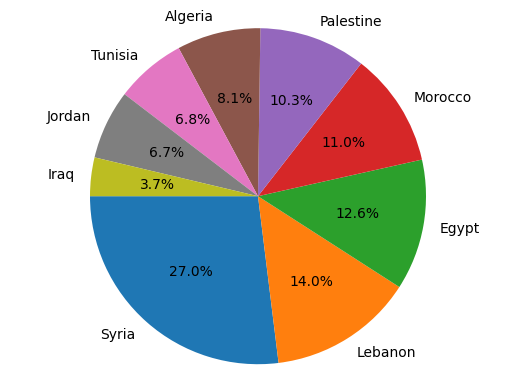

In [ ]:
import matplotlib.pyplot as plt

country_counts =df["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
country_counts =df["Country"].value_counts()
country_counts

Syria        43411
Lebanon      22472
Egypt        20275
Morocco      17687
Palestine    16578
Algeria      12966
Tunisia      10931
Jordan       10749
Iraq          5978
Name: Country, dtype: int64

In [ ]:
from sklearn.utils import resample

# Separate the DataFrame into majority (Syria) and minority classes
majority_class = df[df['Country'] == 'Syria']
minority_classes = df[df['Country'].isin(['Lebanon', 'Egypt', 'Morocco', 'Palestine', 'Algeria', 'Tunisia', 'Jordan', 'Iraq'])]

# Specify the target size for the upsampled majority class
target_size = 26000  # Adjust based on your preferences

# Upsample the majority class to the target size
downsampled_majority = resample(majority_class, replace=True, n_samples=target_size, random_state=42)

# Combine the upsampled majority class with the minority classes
balanced_df = pd.concat([downsampled_majority, minority_classes])

# Shuffle the DataFrame to randomize the order of instances
balanced_df = balanced_df.sample(frac=1, random_state=42)


In [ ]:
balanced_df["Country"].value_counts()

Syria        26000
Lebanon      22472
Egypt        20275
Morocco      17687
Palestine    16578
Algeria      12966
Tunisia      10931
Jordan       10749
Iraq          5978
Name: Country, dtype: int64

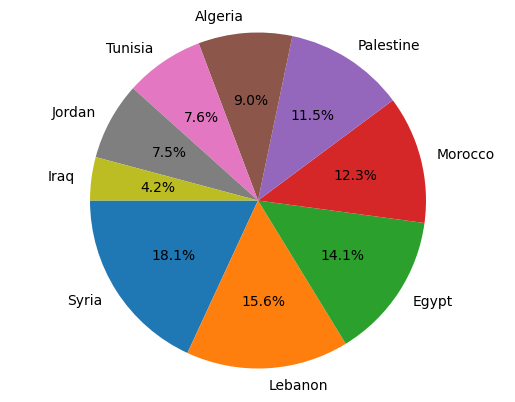

In [ ]:

country_counts =balanced_df["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
majority_class = balanced_df[balanced_df['Country'] == 'Syria']
minority_classes = balanced_df[balanced_df['Country'].isin(['Lebanon', 'Egypt', 'Morocco', 'Palestine', 'Algeria'])]
specific_minority_classes = balanced_df[balanced_df['Country'].isin(['Iraq', 'Jordan', 'Tunisia'])]

target_size = 15000  # Adjust based on your preferences

# Upsample the specific minority classes to the target size
upsampled_specific_minority = pd.concat([resample(specific_minority_class, replace=True, n_samples=target_size, random_state=42) for _, specific_minority_class in specific_minority_classes.groupby('Country')])

# Combine the majority class with the upsampled specific minority classes and other minority classes
balanced_df2 = pd.concat([majority_class, upsampled_specific_minority, minority_classes])

# Shuffle the DataFrame to randomize the order of instances
balanced_df2 = balanced_df2.sample(frac=1, random_state=42)

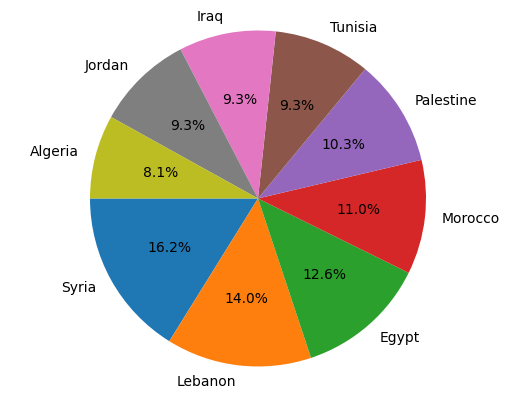

In [ ]:
country_counts =balanced_df2["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
balanced_df2["Country"].value_counts()

Syria        26000
Lebanon      22472
Egypt        20275
Morocco      17687
Palestine    16578
Tunisia      15000
Iraq         15000
Jordan       15000
Algeria      12966
Name: Country, dtype: int64

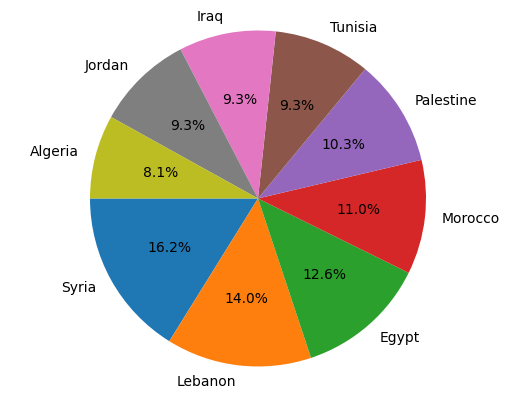

In [ ]:
country_counts =balanced_df2["Country"].value_counts()
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=180)

# Set aspect ratio to be equal, so the pie chart looks circular
plt.axis('equal')

# Display the pie chart
plt.show()

In [ ]:
df=balanced_df2


In [ ]:
import re
import string
from nltk.stem.isri import ISRIStemmer
from nltk.corpus import stopwords
import pyarabic.arabrepr
import nltk


nltk.download('stopwords')
nltk.download('punkt')
stop_words = stopwords.words('arabic')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
def remove_arabic_stopwords(text):
    words = nltk.word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['Sentence'] = df['Sentence'].apply(remove_arabic_stopwords)

In [ ]:
from camel_tools.utils.dediac import dediac_ar
df['Sentence'] = df['Sentence'].apply(dediac_ar)


In [ ]:
from camel_tools.utils.normalize import normalize_unicode

df['Sentence'] = df['Sentence'].apply(normalize_unicode)


In [ ]:
def preprocess_text(text):
    # Remove punctuation
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    # Remove digits
    text = re.sub("\d+", " ", text)
    # Remove longations
    text = re.sub(r'(.)\1+', r"\1", text)
    return text

df['Sentence'] = df['Sentence'].apply(preprocess_text)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import nltk

In [ ]:
texts = df['Sentence'].astype(str)
labels = df['Country']

# Text preprocessing and TF-IDF vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# Naïve Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

# Predicting on test data
predictions = classifier.predict(X_test)

# Evaluating model performance
accuracy = accuracy_score(y_test, predictions)

from sklearn.model_selection import GridSearchCV

# Define a range of alpha values to search
param_grid = {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]}

# Perform grid search
grid_search = GridSearchCV(classifier, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the best alpha
best_alpha = grid_search.best_params_['alpha']
print(f"Best Alpha: {best_alpha}")

# Train the model with the best alpha
best_classifier = MultinomialNB(alpha=best_alpha)
best_classifier.fit(X_train, y_train)

# Predicting on test data with the improved model
best_predictions = best_classifier.predict(X_test)

# Evaluating improved model performance
best_accuracy = accuracy_score(y_test, best_predictions)
print(f"Improved Accuracy: {best_accuracy:.2f}")

print("\nImproved Classification Report:")
print(classification_report(y_test, best_predictions))

Best Alpha: 0.1
Improved Accuracy: 0.86

Improved Classification Report:
              precision    recall  f1-score   support

     Algeria       0.88      0.84      0.86      2522
       Egypt       0.86      0.87      0.86      4159
        Iraq       0.90      0.96      0.93      2983
      Jordan       0.83      0.75      0.79      3034
     Lebanon       0.83      0.77      0.80      4476
     Morocco       0.89      0.89      0.89      3514
   Palestine       0.79      0.73      0.76      3316
       Syria       0.81      0.92      0.86      5229
     Tunisia       0.97      0.96      0.97      2963

    accuracy                           0.86     32196
   macro avg       0.86      0.86      0.86     32196
weighted avg       0.86      0.86      0.85     32196



In [ ]:
from keras.models import Sequential, Model
from keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, Dense
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from keras.callbacks import EarlyStopping

X = df['Sentence'].astype(str)
y = df['Country']

# Tokenize and pad sequences
max_words = 10000
max_sequence_length = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)
X_sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(X_sequences, maxlen=max_sequence_length)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Determine the number of classes
num_classes = len(np.unique(y))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)
# Build the shared embedding layer
embedding_layer = Embedding(input_dim=max_words, output_dim=50, input_length=max_sequence_length)

# the SimpleRNN model
simple_rnn_model = Sequential()
simple_rnn_model.add(embedding_layer)
simple_rnn_model.add(SimpleRNN(128))
simple_rnn_model.add(Dense(32, activation='relu'))
simple_rnn_model.add(Dense(16, activation='relu'))
simple_rnn_model.add(Dense(num_classes, activation='softmax'))

# Compile the SimpleRNN model
simple_rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define Early Stopping for SimpleRNN
early_stopping_simple_rnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the SimpleRNN model with early stopping
simple_rnn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping_simple_rnn])


Epoch 1/100
4025/4025 [==============================] - 118s 29ms/step - loss: 1.2940 - accuracy: 0.5088 - val_loss: 0.8415 - val_accuracy: 0.6954
Epoch 2/100
4025/4025 [==============================] - 124s 31ms/step - loss: 0.7260 - accuracy: 0.7444 - val_loss: 0.7161 - val_accuracy: 0.7494
Epoch 3/100
4025/4025 [==============================] - 111s 28ms/step - loss: 0.5901 - accuracy: 0.7948 - val_loss: 0.6921 - val_accuracy: 0.7605
Epoch 4/100
4025/4025 [==============================] - 115s 29ms/step - loss: 0.5958 - accuracy: 0.7938 - val_loss: 0.7921 - val_accuracy: 0.7215
Epoch 5/100
4025/4025 [==============================] - 110s 27ms/step - loss: 0.5363 - accuracy: 0.8153 - val_loss: 0.6654 - val_accuracy: 0.7744
Epoch 6/100
4025/4025 [==============================] - 112s 28ms/step - loss: 0.4984 - accuracy: 0.8286 - val_loss: 0.6558 - val_accuracy: 0.7804
Epoch 7/100
4025/4025 [==============================] - 113s 28ms/step - loss: 0.5608 - accuracy: 0.8063 - val_

In [ ]:
from sklearn.metrics import classification_report

# Get predictions from the RNN
simple_rnn_predictions = simple_rnn_model.predict(X_padded)

# Convert predictions to class labels
simple_rnn_labels = np.argmax(simple_rnn_predictions, axis=1)

# Show classification report for RNN
print("Classification Report for RNN:")
print(classification_report(y_encoded, simple_rnn_labels))

5031/5031 [==============================] - 40s 8ms/step
Classification Report for RNN:
              precision    recall  f1-score   support

           0       0.86      0.77      0.81     12966
           1       0.90      0.82      0.86     20275
           2       0.87      0.93      0.90     15000
           3       0.74      0.82      0.77     15000
           4       0.88      0.75      0.81     22472
           5       0.89      0.84      0.86     17687
           6       0.70      0.81      0.75     16578
           7       0.91      0.88      0.89     26000
           8       0.80      0.96      0.87     15000

    accuracy                           0.84    160978
   macro avg       0.84      0.84      0.84    160978
weighted avg       0.84      0.84      0.84    160978



1007/1007 [==============================] - 8s 8ms/step


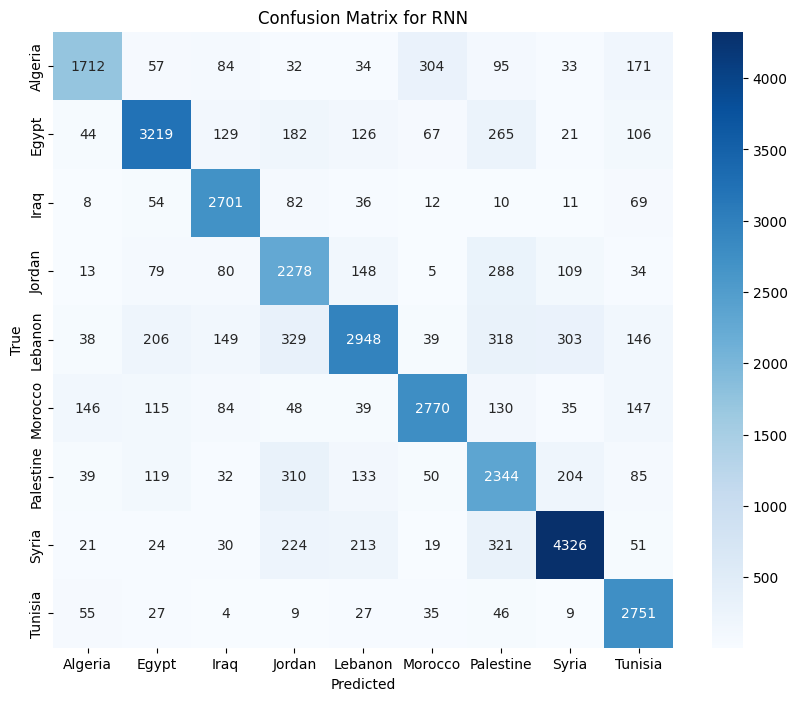

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

# Get predictions from the RNN and LSTM models
rnn_predictions = simple_rnn_model.predict(X_test)

# Convert predictions to class labels
rnn_pred_classes = np.argmax(rnn_predictions, axis=1)

# Create confusion matrices
rnn_conf_matrix = confusion_matrix(y_test, rnn_pred_classes)

# Plot the confusion matrix for RNN
plt.figure(figsize=(10, 8))
sns.heatmap(rnn_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for RNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



In [ ]:

# the LSTM model
lstm_model = Sequential()
lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dense(num_classes, activation='softmax'))

# Compile the LSTM model
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define Early Stopping for LSTM
early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the LSTM model with early stopping
lstm_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping_lstm])

Epoch 1/100
4025/4025 [==============================] - 350s 85ms/step - loss: 0.5194 - accuracy: 0.8225 - val_loss: 0.6075 - val_accuracy: 0.7980
Epoch 2/100
4025/4025 [==============================] - 357s 89ms/step - loss: 0.4103 - accuracy: 0.8594 - val_loss: 0.6054 - val_accuracy: 0.8030
Epoch 3/100
4025/4025 [==============================] - 357s 89ms/step - loss: 0.3635 - accuracy: 0.8734 - val_loss: 0.6031 - val_accuracy: 0.8081
Epoch 4/100
4025/4025 [==============================] - 356s 88ms/step - loss: 0.3250 - accuracy: 0.8868 - val_loss: 0.6299 - val_accuracy: 0.8083
Epoch 5/100
4025/4025 [==============================] - 355s 88ms/step - loss: 0.2931 - accuracy: 0.8976 - val_loss: 0.6631 - val_accuracy: 0.8082
Epoch 6/100
4025/4025 [==============================] - 356s 88ms/step - loss: 0.2671 - accuracy: 0.9055 - val_loss: 0.7087 - val_accuracy: 0.8114


In [ ]:
# Get predictions from the RNN and LSTM models
lstm_predictions = lstm_model.predict(X_padded)

# Convert predictions to class labels
lstm_labels = np.argmax(lstm_predictions, axis=1)



# Show classification report for LSTM
print("\nClassification Report for LSTM:")
print(classification_report(y_encoded, lstm_labels))

5031/5031 [==============================] - 136s 27ms/step

Classification Report for LSTM:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86     12966
           1       0.89      0.89      0.89     20275
           2       0.89      0.96      0.92     15000
           3       0.89      0.83      0.86     15000
           4       0.86      0.85      0.86     22472
           5       0.92      0.87      0.89     17687
           6       0.85      0.81      0.83     16578
           7       0.94      0.92      0.93     26000
           8       0.81      0.98      0.88     15000

    accuracy                           0.88    160978
   macro avg       0.88      0.88      0.88    160978
weighted avg       0.88      0.88      0.88    160978



1007/1007 [==============================] - 26s 26ms/step


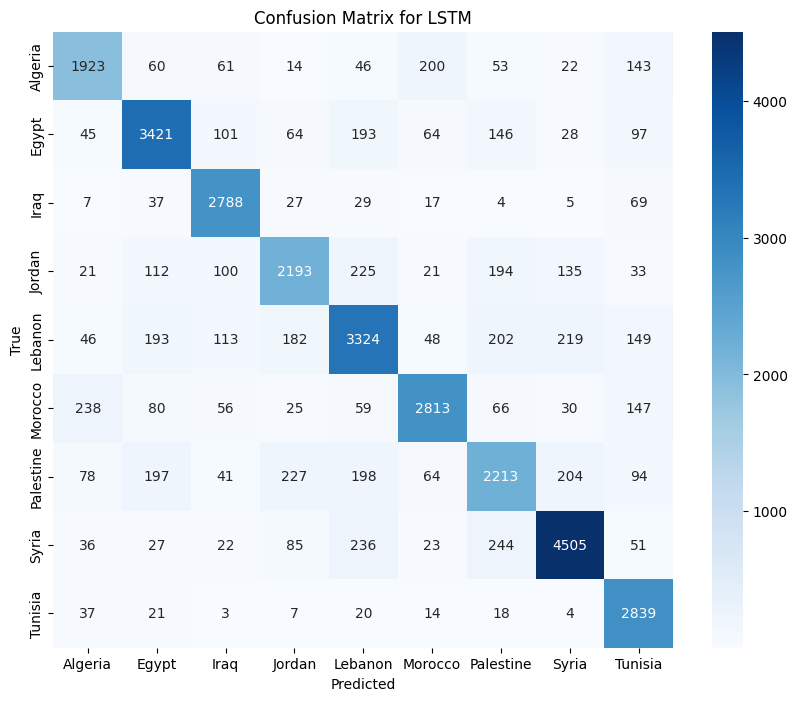

In [ ]:
lstm_predictions = lstm_model.predict(X_test)
lstm_pred_classes = np.argmax(lstm_predictions, axis=1)
lstm_conf_matrix = confusion_matrix(y_test, lstm_pred_classes)
# Plot the confusion matrix for LSTM
plt.figure(figsize=(10, 8))
sns.heatmap(lstm_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for LSTM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
